In [2]:
import pandas as pd
file_path = r"retail_sales_dataset.csv"
df = pd.read_csv(file_path)
print(df)

     Transaction ID        Date Customer ID  Gender  Age Product Category  \
0                 1  2023-11-24     CUST001    Male   34           Beauty   
1                 2  2023-02-27     CUST002  Female   26         Clothing   
2                 3  2023-01-13     CUST003    Male   50      Electronics   
3                 4  2023-05-21     CUST004    Male   37         Clothing   
4                 5  2023-05-06     CUST005    Male   30           Beauty   
..              ...         ...         ...     ...  ...              ...   
995             996  2023-05-16     CUST996    Male   62         Clothing   
996             997  2023-11-17     CUST997    Male   52           Beauty   
997             998  2023-10-29     CUST998  Female   23           Beauty   
998             999  2023-12-05     CUST999  Female   36      Electronics   
999            1000  2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount  
0           3              50

In [ ]:
# NOTE: Here Total amount is redundant b/c it can be calculated by Quantity*Price_per_unit.
# I will keep it for the time being

In [3]:
null_summary = pd.DataFrame({
    "Null Count": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})
print(null_summary)

                  Null Count  Percentage
Transaction ID             0         0.0
Date                       0         0.0
Customer ID                0         0.0
Gender                     0         0.0
Age                        0         0.0
Product Category           0         0.0
Quantity                   0         0.0
Price per Unit             0         0.0
Total Amount               0         0.0


In [4]:
# lets remove transaction ID
df = df.drop('Transaction ID', axis=1)

In [8]:
# lets look at descriptive stats
df.describe()

# 25% for column Age: The number 29 means that 25% of data is below 29 
# 50% for column Age: The number 42 means that 50% of data is below 42
# 68% of people Age is between (41-13=) 28 and (41+13=) 58

,Age,Quantity,Price per Unit,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


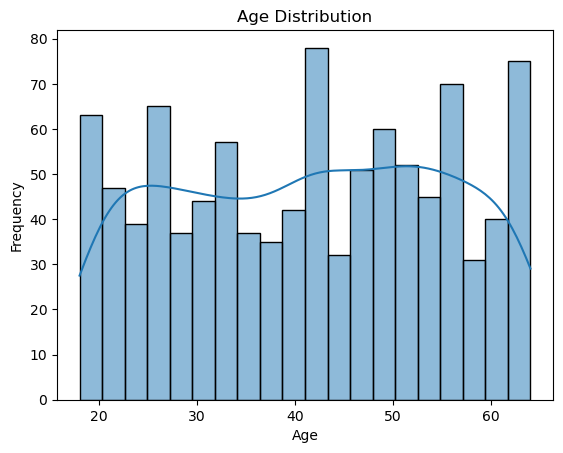

In [8]:
# Distribution of Age: Histogram + KDE (Kernel Density Estimate)

import seaborn as sns
import matplotlib.pyplot as plt

# Histogram + KDE (Kernel Density Estimate)
sns.histplot(df['Age'], kde=True, bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


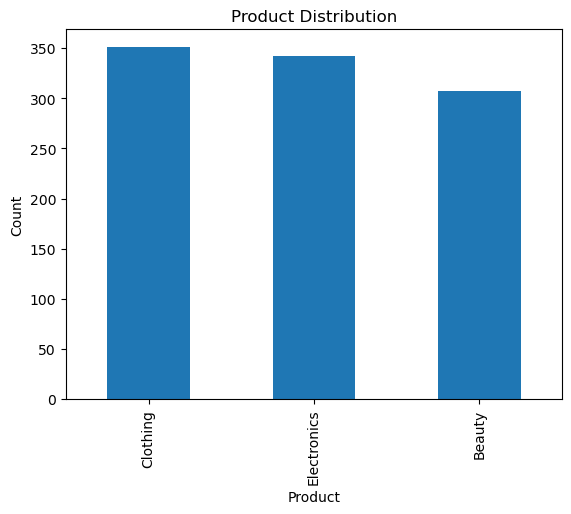

In [9]:
 # Distribution of Product Category: 
df['Product Category'].value_counts().plot(kind='bar')

plt.title("Product Distribution")
plt.xlabel("Product")
plt.ylabel("Count")
plt.show()


In [12]:
# Find for jan , when did the max/min sales occured

df['Date'] = pd.to_datetime(df['Date']) # Make sure 'Date' is in datetime format
                          
date_sales = df[(df['Date'] >= '2023-01-01') & (df['Date'] <= '2023-01-31')]  # # Filter data between 2023-01-01 and 2023-01-31

date_sale = df.groupby('Date')['Total Amount'].sum().reset_index().sort_values('Date')  # Group by date and get total amount


max_sale_value = date_sale[date_sale['Total Amount']==date_sale['Total Amount'].max()] # which date maximum sales

min_sale_value = date_sale[date_sale['Total Amount']==date_sale['Total Amount'].min()] # which date minimum sales


print(f"date_sale: \n{date_sale}") # final result
print("##########################")

print(f"max_sale_value: \n{max_sale_value}")
print("##########################")
print(f"min_sale_value: \n{min_sale_value}")

date_sale: 
          Date  Total Amount
0   2023-01-01          3600
1   2023-01-02          1765
2   2023-01-03           600
3   2023-01-04          1240
4   2023-01-05          1100
..         ...           ...
340 2023-12-27           700
341 2023-12-28          2075
342 2023-12-29          3400
343 2023-12-31            50
344 2024-01-01          1530

[345 rows x 2 columns]
##########################
max_sale_value: 
          Date  Total Amount
134 2023-05-23          8455
##########################
min_sale_value: 
         Date  Total Amount
63 2023-03-08            25
98 2023-04-17            25


In [18]:
# Here I want to see all the months and Years and how many records there are for each
df['month'] = df['Date'].dt.strftime('%B')
df['year'] = df['Date'].dt.strftime('%Y')

print(df.value_counts(['year', 'month']))

year  month    
2023  May          105
      October       96
      August        94
      December      91
      April         86
      February      85
      November      78
      June          77
      January       76
      March         73
      July          72
      September     65
2024  January        2
Name: count, dtype: int64


In [15]:
# I want to see the date range
# Find min and max date
print("Earliest date:", df['Date'].min())
print("Latest date:", df['Date'].max())

date_range = df['Date'].max() - df['Date'].min()
print("Range of days:", date_range)

Earliest date: 2023-01-01 00:00:00
Latest date: 2024-01-01 00:00:00
Range of days: 365 days 00:00:00


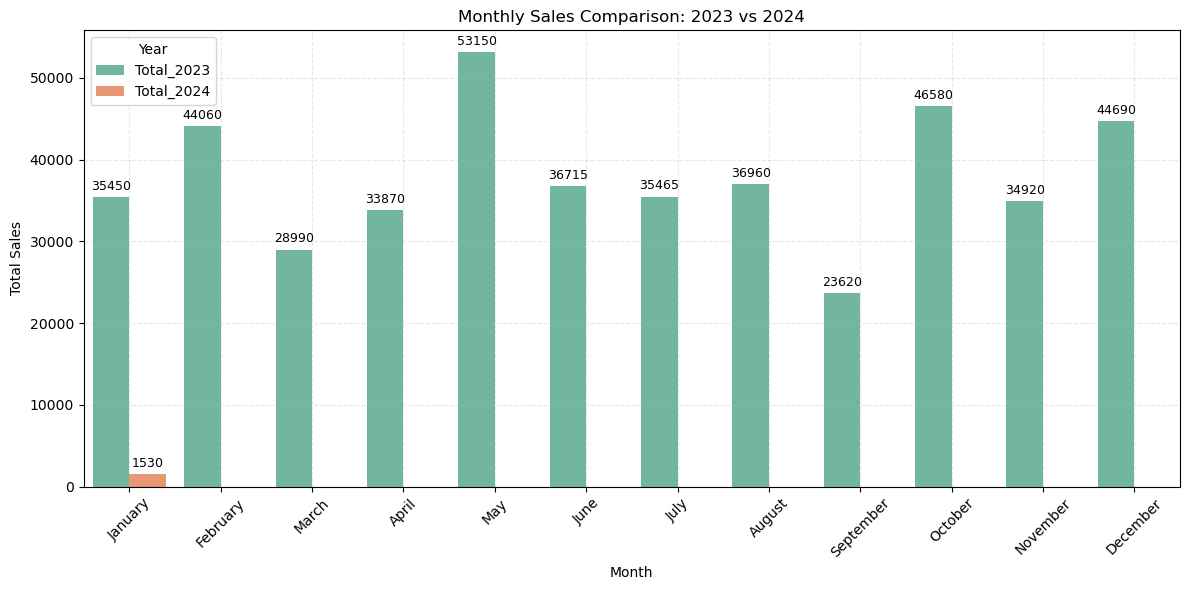

In [20]:
# Monthly sales analsis

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Make sure Month_Name exists
df['month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

# Filter year
Month_Year_Sales2023 = df[df['Year'] == 2023]
Month_Year_Sales2024 = df[df['Year'] == 2024]

# Year-wise sales
Month_Year_Sales2023 = Month_Year_Sales2023.groupby('month')['Total Amount'].sum().reset_index()
Month_Year_Sales2024 = Month_Year_Sales2024.groupby('month')['Total Amount'].sum().reset_index()

# Rename columns
Month_Year_Sales2023 = Month_Year_Sales2023.rename(columns={'Total Amount': 'Total_2023'})
Month_Year_Sales2024 = Month_Year_Sales2024.rename(columns={'Total Amount': 'Total_2024'})

# Merge data
combine = pd.merge(Month_Year_Sales2023, Month_Year_Sales2024, on='month', how='outer')

# Sort by calendar order
from calendar import month_name
month_order = list(month_name)[1:]  # Skip empty first entry

combine['month'] = pd.Categorical(combine['month'], categories=month_order, ordered=True)
combine = combine.sort_values('month')

# Melt for seaborn
melted = combine.melt(id_vars='month', value_vars=['Total_2023', 'Total_2024'],
                      var_name='Year', value_name='Sales')

# Plot
plt.figure(figsize=(12, 6))
ax=sns.barplot(data=melted, x='month', y='Sales', hue='Year', palette='Set2')


for container in ax.containers:
    ax.bar_label(container,fmt='%.0f',padding=3,fontsize=9)

    
plt.xticks(rotation=45)
plt.title('Monthly Sales Comparison: 2023 vs 2024')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


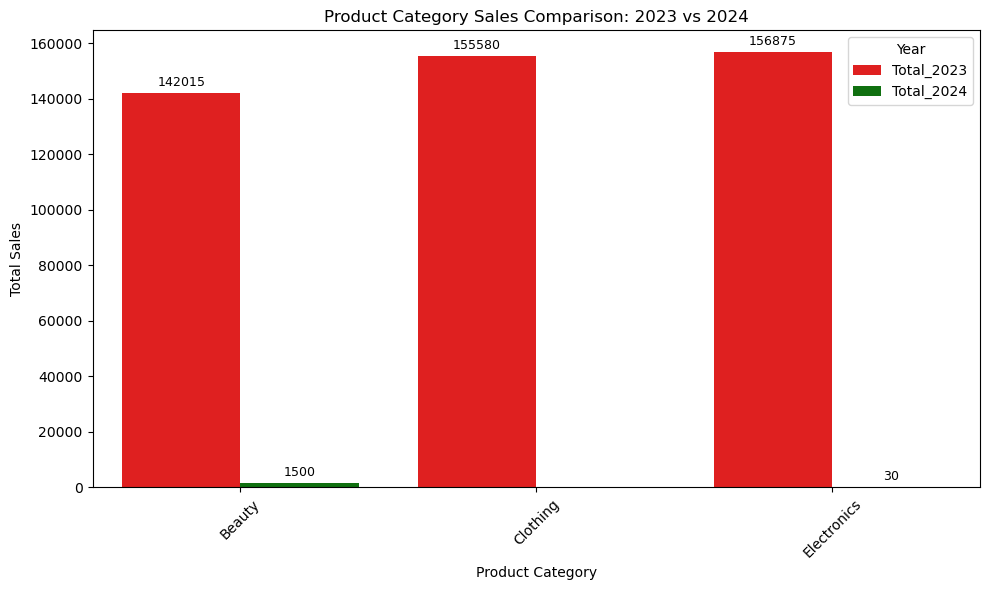

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sales analsis by Product Category
df['Year'] = df['Date'].dt.year
Product_Cat2023 = df[df['Year'] == 2023]

Product_Cat2023 = Product_Cat2023.groupby('Product Category')['Total Amount'].sum().reset_index() # catergory wise grouping sales
Product_Cat2023 = Product_Cat2023.rename(columns={'Total Amount': 'Total_2023'})

Product_Cat2024 = df[df['Year'] == 2024]

Product_Cat2024 = Product_Cat2024.groupby('Product Category')['Total Amount'].sum().reset_index() # catergory wise grouping sales
Product_Cat2024 = Product_Cat2024.rename(columns={'Total Amount': 'Total_2024'})

combine = pd.merge(Product_Cat2023,Product_Cat2024,on='Product Category',how='outer')

melted = combine.melt(id_vars='Product Category', value_vars=['Total_2023', 'Total_2024'], var_name='Year', value_name='Sales')

plt.figure(figsize=(10,6))

palette = {'Total_2023': 'Red', 'Total_2024': 'Green'} 
ax=sns.barplot(x='Product Category', y='Sales', hue='Year', data=melted,palette=palette)
plt.title('Product Category Sales Comparison: 2023 vs 2024')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container,fmt='%.0f',padding=3,fontsize=9)
plt.tight_layout()
plt.show()

   Gender  Total Sales
1    Male       223160
0  Female       232840


<Figure size 1000x600 with 0 Axes>

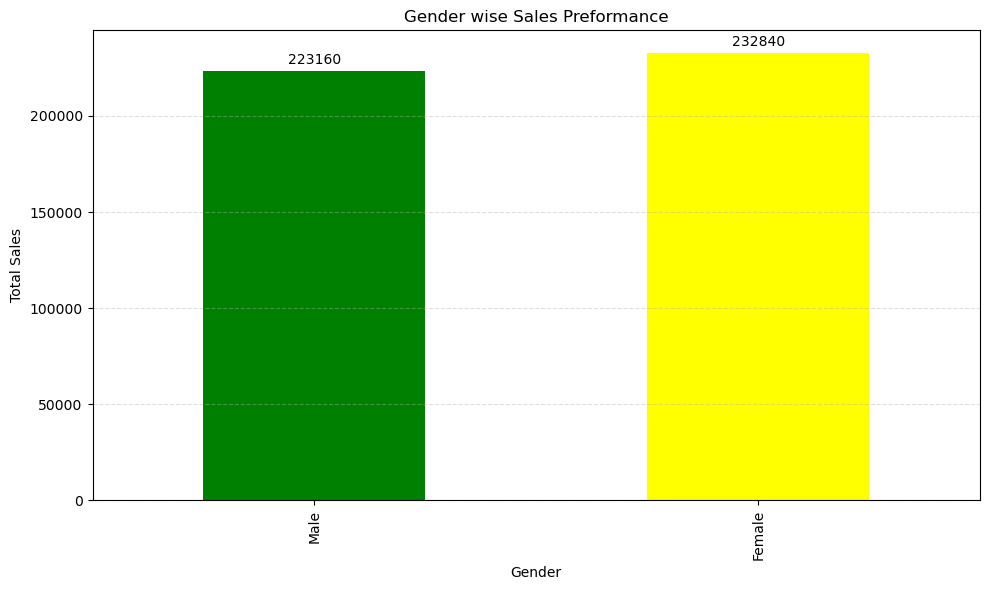

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

Genderwisesales = df.groupby('Gender')['Total Amount'].sum().reset_index().sort_values('Total Amount')
Genderwisesales = Genderwisesales.rename(columns={'Total Amount':'Total Sales'})
print(Genderwisesales)

plt.figure(figsize=(10,6))
ax = Genderwisesales.plot(kind='bar', x='Gender', y='Total Sales', figsize=(10,6), color=['Green', 'Yellow'],legend=False)
plt.title('Gender wise Sales Preformance')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.grid(axis='y',linestyle='--',alpha=0.4)
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(container,fmt='%d',label_type='edge',padding=3)
plt.show()

         AgeGroup  Total Sales
0        18 to 22        61015
1        23 to 27        46900
2        28 to 32        40800
3        33 to 37        55070
4  38 to above 60       252215


<Figure size 1000x600 with 0 Axes>

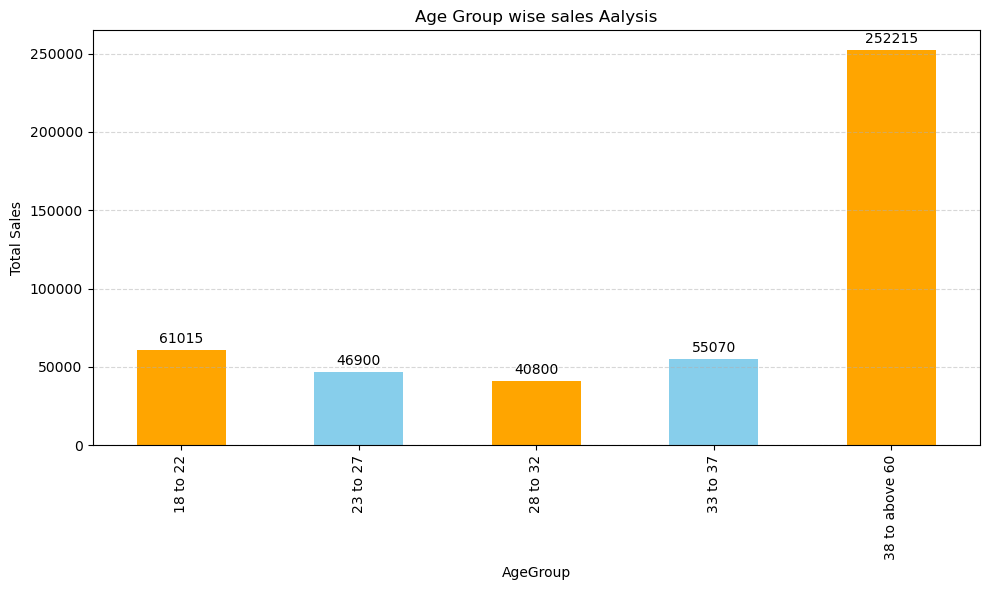

In [8]:
# I want to see how much sales happened for different age groups
import pandas as pd
import matplotlib.pyplot as plt
# Create function for grouping age category 
def ageg(age):
    if age <= 22:
        return '18 to 22'
    elif age <= 27:
        return '23 to 27'
    elif age <= 32:
        return '28 to 32'
    elif age <= 37:
        return '33 to 37'
    else:
        return '38 to above 60'

df['AgeGroup'] = df['Age'].apply(ageg)

AgeGroupwise=df.groupby('AgeGroup')['Total Amount'].sum().reset_index() # sum sales of age group wise
# Rename column
AgeGroupwise = AgeGroupwise.rename(columns={'Total Amount': 'Total Sales'})
print(AgeGroupwise)

plt.figure(figsize=(10,6))

ax = AgeGroupwise.plot(kind='bar', x='AgeGroup',y='Total Sales', figsize=(10,6), color=['orange','skyblue'],legend=False)


plt.title('Age Group wise sales Aalysis')
plt.xlabel('AgeGroup')
plt.ylabel('Total Sales')
plt.grid(axis='y',linestyle='--',alpha=0.5)
#plt.legend(title='AgeGroup')
plt.tight_layout()

# Add bar label
for container in ax.containers:
    ax.bar_label(container,fmt='%d',label_type='edge',padding=3)
plt.show()

Product Category  Beauty  Clothing  Electronics
AgeGroup                                       
18 to 22           25380     15690        19945
23 to 27           12370     23760        10770
28 to 32           10040     17860        12900
33 to 37           19675     17855        17540
38 to above 60     76050     80415        95750


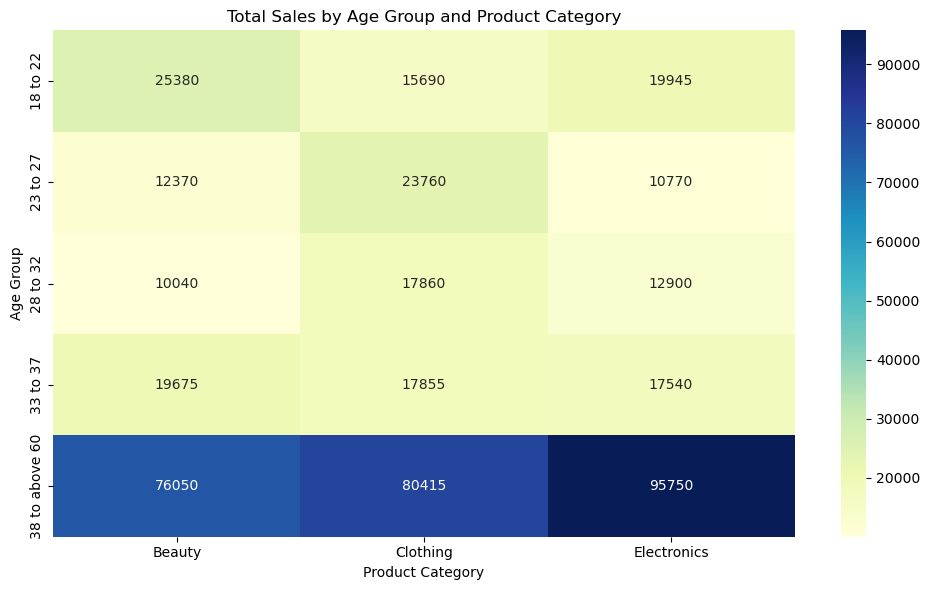

In [20]:
# Now I want to see how much sales was for each Product category based on Age group range

import seaborn as sns
import matplotlib.pyplot as plt

# Group by Age Group and Product Category simultaneously
combined = df.groupby(['AgeGroup', 'Product Category'])['Total Amount'].sum().reset_index()

# Rename column for better understanding
combined = combined.rename(columns={'Total Amount': 'Total Sales'})

# Pivot the data for a clearer matrix view
pivot_table = combined.pivot(index='AgeGroup', columns='Product Category', values='Total Sales')

# Display the pivot table
print(pivot_table)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap="YlGnBu")
plt.title("Total Sales by Age Group and Product Category")
plt.xlabel("Product Category")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()
